# 🎮 Q-Learning — iesirea din labirint in care exista si un capcaun

Un agent (🧍) trebuie sa ajunga la **iesire** (🟩) fara a fi prins de **capcaun** (👹).

| Element | Simbol | Pozitie initiala |
|---|---|---|
| Agent | `A` | (3, 0) — stanga |
| Capcaun | `C` | (0, 6) — dreapta-sus |
| Iesire | `E` | (3, 6) — dreapta-centru |

**Reguli:**
- Agentul si capcaunul se misca pe rand (agent → capcaun)
- Capcaunul urmareste agentul **greedy** (se apropie cat poate)
- Grid: **7×7**, actiuni: `Sus / Jos / Stanga / Dreapta`

**Reward:**
- `+100` → agent ajunge la iesire
- `−100` → agent prins de capcaun
- `−1` per pas (penalizare timp)

**Spatiu de stari:** `(rand_agent, col_agent, rand_capcaun, col_capcaun)

**Formula Q-Learning:**
$$Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma \max_{a'}Q(s',a') - Q(s,a)\right]$$

## 1. Importuri

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import clear_output
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Importuri complete!')

Importuri complete!


## 2. Configurare mediu

In [13]:
# ─── Constante mediu ──────────────────────────────────────────────
G        = 4                  # dimensiune grid G x G
A_START  = (3, 0)             # pozitie initiala agent
C_START  = (0, 2)             # pozitie initiala capcaun
EXIT     = (3, 3)             # iesire

# Actiuni: 0=Sus, 1=Jos, 2=Stanga, 3=Dreapta
DR = [-1, 1,  0, 0]
DC = [ 0, 0, -1, 1]
ACTION_NAMES = ['Sus', 'Jos', 'Stanga', 'Dreapta']
ACTION_ARROWS= ['↑',   '↓',   '←',      '→']

# ─── Reward ──────────────────────────────────────────────────────
R_WIN  =  100
R_LOSE = -100
R_STEP =   -1

N_STATES  = G * G * G * G    # 2401
N_ACTIONS = 4

print(f'Grid: {G}×{G}  |  Stari: {N_STATES}  |  Actiuni: {N_ACTIONS}')
print(f'Agent start: {A_START}  |  Capcaun start: {C_START}  |  Iesire: {EXIT}')

Grid: 4×4  |  Stari: 256  |  Actiuni: 4
Agent start: (3, 0)  |  Capcaun start: (0, 2)  |  Iesire: (3, 3)


## 3. Logica mediului

In [4]:
def state_id(ar, ac, cr, cc):
    """Encode (agent_row, agent_col, capcaun_row, capcaun_col) → index integer."""
    return ((ar * G + ac) * G + cr) * G + cc


def valid_actions(r, c):
    """Returneaza actiunile valide din celula (r, c)."""
    return [a for a in range(N_ACTIONS)
            if 0 <= r + DR[a] < G and 0 <= c + DC[a] < G]


def capcaun_move(cr, cc, ar, ac):
    """Capcaunul se misca greedy spre agent (minimizeaza distanta Manhattan)."""
    best_d = abs(cr - ar) + abs(cc - ac)
    br, bc = cr, cc
    for a in range(N_ACTIONS):
        nr, nc = cr + DR[a], cc + DC[a]
        if 0 <= nr < G and 0 <= nc < G:
            d = abs(nr - ar) + abs(nc - ac)
            if d < best_d:
                best_d, br, bc = d, nr, nc
    return br, bc


def step(ar, ac, cr, cc, action):
    """
    Executa un pas in mediu.
    Returneaza (next_ar, next_ac, next_cr, next_cc, reward, done, info)
    """
    # Mișcare agent
    nar = ar + DR[action]
    nac = ac + DC[action]
    if not (0 <= nar < G and 0 <= nac < G):   # actiune invalida → stai pe loc
        nar, nac = ar, ac

    # Verificare victorie
    if (nar, nac) == EXIT:
        return nar, nac, cr, cc, R_WIN, True, 'win'

    # Miscare capcaun
    ncr, ncc = capcaun_move(cr, cc, nar, nac)

    # Verificare prindere
    if nar == ncr and nac == ncc:
        return nar, nac, ncr, ncc, R_LOSE, True, 'lose'

    return nar, nac, ncr, ncc, R_STEP, False, 'ongoing'


def reset():
    """Reseteaza mediul si returneaza starea initiala."""
    return A_START[0], A_START[1], C_START[0], C_START[1]


print('Functii mediu definite!')

Functii mediu definite!


## 4. Vizualizare grid

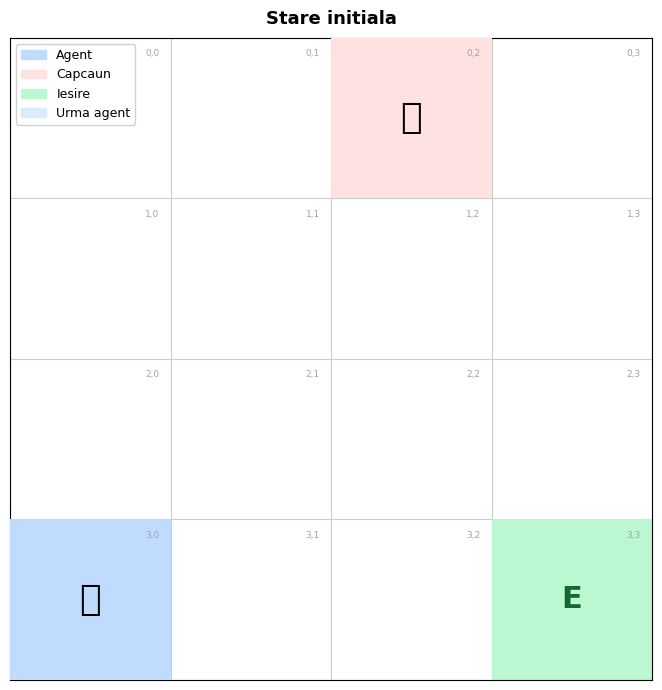

In [5]:
def render_grid(ar, ac, cr, cc, trail=None, title='', q_table=None, show_policy=False):
    """
    Afiseaza gridul cu:
     - agentul (albastru), capcaunul (rosu), iesirea (verde)
     - urma agentului (albastru deschis)
     - optional: politica Q (sageti pe fiecare celula)
    """
    fig, ax = plt.subplots(figsize=(7, 7))

    # Background grid
    grid_bg = np.ones((G, G, 3))  # alb
    ax.imshow(grid_bg, extent=[0, G, 0, G], origin='upper', zorder=0)

    # Linii de grid
    for i in range(G + 1):
        ax.axhline(i, color='#cccccc', linewidth=0.8, zorder=1)
        ax.axvline(i, color='#cccccc', linewidth=0.8, zorder=1)

    # Coordonate matplotlib: ax.add_patch foloseste (col, G-1-row) pentru origin='upper'
    def cx(col): return col + 0.5
    def cy(row): return G - row - 0.5

    # Urma agentului
    if trail:
        for (tr, tc) in trail:
            rect = plt.Rectangle((tc, G-tr-1), 1, 1,
                                  facecolor='#dbeafe', edgecolor='none', zorder=2)
            ax.add_patch(rect)

    # Iesire
    rect = plt.Rectangle((EXIT[1], G-EXIT[0]-1), 1, 1,
                          facecolor='#bbf7d0', edgecolor='none', zorder=2)
    ax.add_patch(rect)
    ax.text(cx(EXIT[1]), cy(EXIT[0]), 'E', ha='center', va='center',
            fontsize=22, fontweight='bold', color='#166534', zorder=5)

    # Politica Q (sageti)
    if show_policy and q_table is not None:
        for r in range(G):
            for c in range(G):
                if (r, c) == EXIT: continue
                if (r, c) == (ar, ac): continue
                if (r, c) == (cr, cc): continue
                sid = state_id(r, c, cr, cc)
                qv = q_table[sid]
                va = valid_actions(r, c)
                ba = va[np.argmax(qv[va])]
                ax.text(cx(c), cy(r), ACTION_ARROWS[ba],
                        ha='center', va='center', fontsize=14,
                        color='#6b7280', alpha=0.55, zorder=3)

    # Capcaun
    rect = plt.Rectangle((cc, G-cr-1), 1, 1,
                          facecolor='#fee2e2', edgecolor='none', zorder=3)
    ax.add_patch(rect)
    ax.text(cx(cc), cy(cr), '👹', ha='center', va='center',
            fontsize=26, zorder=6)

    # Agent
    rect = plt.Rectangle((ac, G-ar-1), 1, 1,
                          facecolor='#bfdbfe', edgecolor='none', zorder=3)
    ax.add_patch(rect)
    ax.text(cx(ac), cy(ar), '🧍', ha='center', va='center',
            fontsize=26, zorder=6)

    # Etichete coordonate
    for r in range(G):
        for c in range(G):
            ax.text(c + 0.93, G - r - 0.07, f'{r},{c}',
                    ha='right', va='top', fontsize=6.5,
                    color='#9ca3af', zorder=7)

    ax.set_xlim(0, G)
    ax.set_ylim(0, G)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

    legend = [
        mpatches.Patch(color='#bfdbfe', label='Agent'),
        mpatches.Patch(color='#fee2e2', label='Capcaun'),
        mpatches.Patch(color='#bbf7d0', label='Iesire'),
        mpatches.Patch(color='#dbeafe', label='Urma agent'),
    ]
    ax.legend(handles=legend, loc='upper left',
              fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()


# Test: stare inițială
ar, ac, cr, cc = reset()
render_grid(ar, ac, cr, cc, title='Stare initiala')

## 5. Hiperparametri Q-Learning

In [6]:
# ─── Hiperparametri ───────────────────────────────────────────────
ALPHA         = 0.10      # rata de învatare
GAMMA         = 0.95      # factor discount
EPSILON_START = 1.00      # explorare initiala
EPSILON_END   = 0.01      # explorare minima
EPSILON_DECAY = 0.9994    # decay per episod

N_TRAIN       = 5_000     # episoade antrenare
MAX_STEPS     = 120       # pași maximi per episod

EVAL_INTERVAL = 500       # evaluare periodică
N_EVAL        = 200       # episoade per evaluare

print('=== Hiperparametri ===')
print(f'  α = {ALPHA}, γ = {GAMMA}')
print(f'  ε: {EPSILON_START} → {EPSILON_END} (decay={EPSILON_DECAY})')
print(f'  Antrenare: {N_TRAIN:,} episoade, max {MAX_STEPS} pași/ep')
print(f'  Evaluare la fiecare {EVAL_INTERVAL} episoade ({N_EVAL} ep test)')

=== Hiperparametri ===
  α = 0.1, γ = 0.95
  ε: 1.0 → 0.01 (decay=0.9994)
  Antrenare: 5,000 episoade, max 120 pași/ep
  Evaluare la fiecare 500 episoade (200 ep test)


## 6. Inițializare Q-Table

In [7]:
Q = np.zeros((N_STATES, N_ACTIONS))

print(f'Q-table shape : {Q.shape}')
print(f'Memorie       : {Q.nbytes / 1024:.1f} KB')
print(f'Intrări totale: {Q.size:,}')

Q-table shape : (256, 4)
Memorie       : 8.0 KB
Intrări totale: 1,024


## 7. Funcții agent

In [8]:
def epsilon_greedy(Q, ar, ac, cr, cc, epsilon):
    """Politica ε-greedy: explorare aleatoare vs. cea mai buna actiune."""
    va = valid_actions(ar, ac)
    if np.random.random() < epsilon:
        return np.random.choice(va)
    sid = state_id(ar, ac, cr, cc)
    return va[np.argmax(Q[sid, va])]

def greedy(Q, ar, ac, cr, cc):
    """Politica greedy pura (ε=0) pentru evaluare."""
    return epsilon_greedy(Q, ar, ac, cr, cc, epsilon=0.0)

def q_update(Q, ar, ac, cr, cc, action,
             reward, nar, nac, ncr, ncc, done):
    """Actualizare Q-table."""
    sid_cur  = state_id(ar,  ac,  cr,  cc)
    sid_next = state_id(nar, nac, ncr, ncc)
    max_next = 0.0 if done else np.max(Q[sid_next, valid_actions(nar, nac)])
    td_error = reward + GAMMA * max_next - Q[sid_cur, action]
    Q[sid_cur, action] += ALPHA * td_error
    return abs(td_error)

def evaluate(Q, n_episodes=200):
    """
    Ruleaza agentul greedy (ε=0) si returneaza metrici:
      - success_rate  : % episoade caștigate
      - reward_mean   : reward mediu
      - steps_mean    : pasi medii per episod castigat
    """
    wins, rewards, steps_win = 0, [], []
    for _ in range(n_episodes):
        ar, ac, cr, cc = reset()
        total_r = 0
        for t in range(MAX_STEPS):
            a = greedy(Q, ar, ac, cr, cc)
            ar, ac, cr, cc, r, done, info = step(ar, ac, cr, cc, a)
            total_r += r
            if done:
                if info == 'win':
                    wins += 1
                    steps_win.append(t + 1)
                break
        rewards.append(total_r)
    return {
        'success_rate': wins / n_episodes * 100,
        'reward_mean' : np.mean(rewards),
        'steps_mean'  : np.mean(steps_win) if steps_win else MAX_STEPS,
    }

## 8. Antrenare Q-Learning

In [9]:
# ─── Logging ─────────────────────────────────────────────────────
train_rewards   = []
train_steps     = []
train_outcomes  = []      # 'win' / 'lose' / 'timeout'
td_errors_log   = []
eps_log         = []
eval_ckpts      = []      # metrici periodice

epsilon = EPSILON_START
Q.fill(0)

# ─── Baseline (agent random inainte de antrenare) ─────────────────
Q_random = np.zeros_like(Q)
baseline = evaluate(Q_random, n_episodes=200)
print('=== Baseline (agent random) ===')
for k, v in baseline.items():
    print(f'  {k:<15}: {v:.2f}')
print()

# ─── Training loop ────────────────────────────────────────────────
t0 = time.time()
print(f'Start antrenare: {N_TRAIN:,} episoade...')

for ep in range(N_TRAIN):
    ar, ac, cr, cc = reset()
    ep_reward = 0.0
    ep_td     = []
    outcome   = 'timeout'

    for t in range(MAX_STEPS):
        action = epsilon_greedy(Q, ar, ac, cr, cc, epsilon)
        nar, nac, ncr, ncc, reward, done, info = step(ar, ac, cr, cc, action)

        td = q_update(Q, ar, ac, cr, cc, action,
                      reward, nar, nac, ncr, ncc, done)
        ep_td.append(td)
        ep_reward += reward
        ar, ac, cr, cc = nar, nac, ncr, ncc

        if done:
            outcome = info
            break

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    train_rewards.append(ep_reward)
    train_steps.append(t + 1)
    train_outcomes.append(outcome)
    td_errors_log.append(np.mean(ep_td))
    eps_log.append(epsilon)

    # Evaluare periodica
    if (ep + 1) % EVAL_INTERVAL == 0:
        m = evaluate(Q, n_episodes=N_EVAL)
        m['episode'] = ep + 1
        m['epsilon'] = epsilon
        eval_ckpts.append(m)
        recent_wr = train_outcomes[-EVAL_INTERVAL:].count('win') / EVAL_INTERVAL * 100
        print(f'  Ep {ep+1:>6,} | ε={epsilon:.4f} | '
              f'WinRate(train)={recent_wr:5.1f}% | '
              f'WinRate(test)={m["success_rate"]:5.1f}% | '
              f'Steps={m["steps_mean"]:5.1f} | '
              f'{time.time()-t0:.0f}s')

print(f'\n Antrenare finalizata in {time.time()-t0:.1f}s')

=== Baseline (agent random) ===
  success_rate   : 0.00
  reward_mean    : -120.00
  steps_mean     : 120.00

Start antrenare: 5,000 episoade...
  Ep    500 | ε=0.7408 | WinRate(train)= 10.2% | WinRate(test)=100.0% | Steps=  3.0 | 0s
  Ep  1,000 | ε=0.5487 | WinRate(train)= 24.4% | WinRate(test)=100.0% | Steps=  3.0 | 0s
  Ep  1,500 | ε=0.4065 | WinRate(train)= 35.8% | WinRate(test)=100.0% | Steps=  3.0 | 0s
  Ep  2,000 | ε=0.3011 | WinRate(train)= 51.4% | WinRate(test)=100.0% | Steps=  3.0 | 1s
  Ep  2,500 | ε=0.2230 | WinRate(train)= 60.4% | WinRate(test)=100.0% | Steps=  3.0 | 1s
  Ep  3,000 | ε=0.1652 | WinRate(train)= 69.4% | WinRate(test)=100.0% | Steps=  3.0 | 1s
  Ep  3,500 | ε=0.1224 | WinRate(train)= 76.0% | WinRate(test)=100.0% | Steps=  3.0 | 1s
  Ep  4,000 | ε=0.0907 | WinRate(train)= 80.0% | WinRate(test)=100.0% | Steps=  3.0 | 1s
  Ep  4,500 | ε=0.0672 | WinRate(train)= 86.2% | WinRate(test)=100.0% | Steps=  3.0 | 1s
  Ep  5,000 | ε=0.0497 | WinRate(train)= 90.6% | WinRa

## 9. Evaluare Finală — Train vs. Test

In [10]:
final = evaluate(Q, n_episodes=500)

print('=' * 58)
print('        EVALUARE FINALA  (500 episoade test, greedy)')
print('=' * 58)
print(f"{'MetricA':<20} {'Random (baseline)':>18} {'Q-Learning':>12}")
print('-' * 58)
keys = [('success_rate','Rata succes (%)'),
        ('reward_mean', 'Reward mediu'),
        ('steps_mean',  'Pasi medii (win)')]
for k, label in keys:
    print(f"{label:<20} {baseline[k]:>18.2f} {final[k]:>12.2f}")
print('=' * 58)

# Win rate pe antrenare (ultimele 1000 ep)
wr_last = train_outcomes[-1000:].count('win') / min(1000, N_TRAIN) * 100
print(f'\nWin rate (ultimele 1000 ep train): {wr_last:.1f}%')
print(f'Win rate (test final, greedy)     : {final["success_rate"]:.1f}%')

        EVALUARE FINALA  (500 episoade test, greedy)
MetricA               Random (baseline)   Q-Learning
----------------------------------------------------------
Rata succes (%)                    0.00       100.00
Reward mediu                    -120.00        98.00
Pasi medii (win)                 120.00         3.00

Win rate (ultimele 1000 ep train): 88.4%
Win rate (test final, greedy)     : 100.0%


## 10. Grafice de antrenare

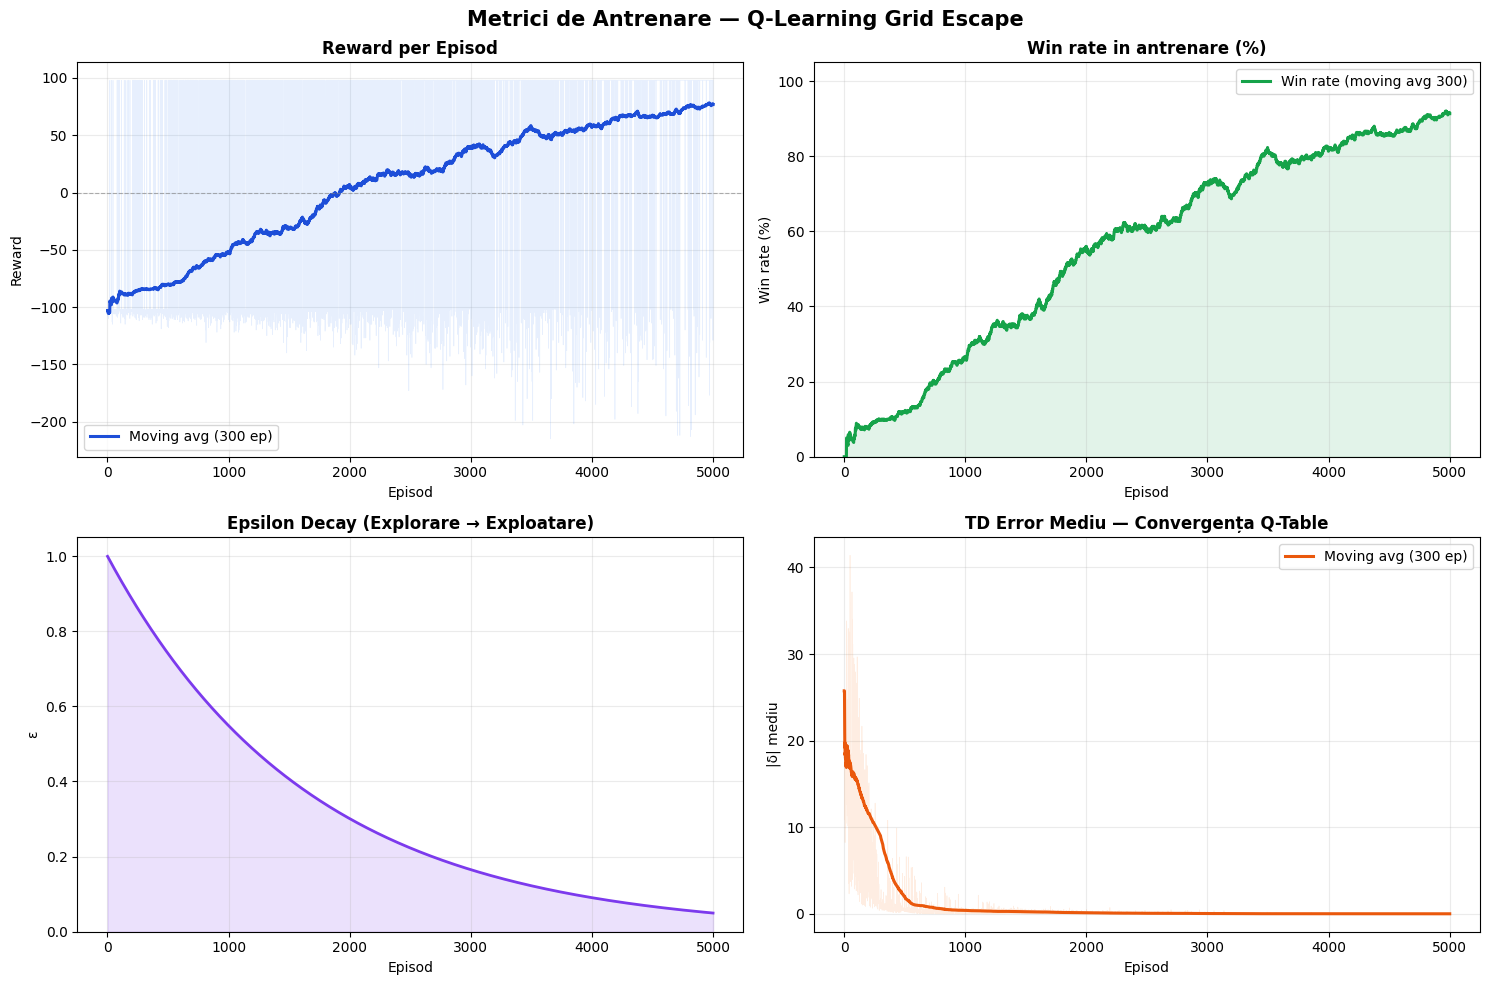

In [11]:
def moving_avg(arr, w=300):
    import pandas as pd
    return pd.Series(arr).rolling(w, min_periods=1).mean().values

win_per_ep = [1 if o == 'win' else 0 for o in train_outcomes]
eps_arr    = np.arange(1, N_TRAIN + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Metrici de Antrenare — Q-Learning Grid Escape',
             fontsize=15, fontweight='bold')

# ── Reward ────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(eps_arr, train_rewards, alpha=0.12, color='#3b82f6', lw=0.5)
ax.plot(eps_arr, moving_avg(train_rewards, 300),
        color='#1d4ed8', lw=2.2, label='Moving avg (300 ep)')
ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.set_title('Reward per Episod', fontweight='bold')
ax.set_xlabel('Episod'); ax.set_ylabel('Reward')
ax.legend(); ax.grid(True, alpha=0.25)

# ── Win rate ──────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(eps_arr, moving_avg(win_per_ep, 300) * 100,
        color='#16a34a', lw=2.2, label='Win rate (moving avg 300)')
ax.fill_between(eps_arr, moving_avg(win_per_ep, 300) * 100,
                alpha=0.12, color='#16a34a')
ax.set_title('Win rate in antrenare (%)', fontweight='bold')
ax.set_xlabel('Episod'); ax.set_ylabel('Win rate (%)')
ax.set_ylim(0, 105); ax.legend(); ax.grid(True, alpha=0.25)

# ── Epsilon decay ─────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(eps_arr, eps_log, color='#7c3aed', lw=2)
ax.fill_between(eps_arr, eps_log, alpha=0.15, color='#7c3aed')
ax.set_title('Epsilon Decay (Explorare → Exploatare)', fontweight='bold')
ax.set_xlabel('Episod'); ax.set_ylabel('ε'); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.25)

# ── TD Error ──────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(eps_arr, td_errors_log, alpha=0.12, color='#f97316', lw=0.5)
ax.plot(eps_arr, moving_avg(td_errors_log, 300),
        color='#ea580c', lw=2.2, label='Moving avg (300 ep)')
ax.set_title('TD Error Mediu — Convergența Q-Table', fontweight='bold')
ax.set_xlabel('Episod'); ax.set_ylabel('|δ| mediu')
ax.legend(); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 12. Parcurgere grid pas cu pas

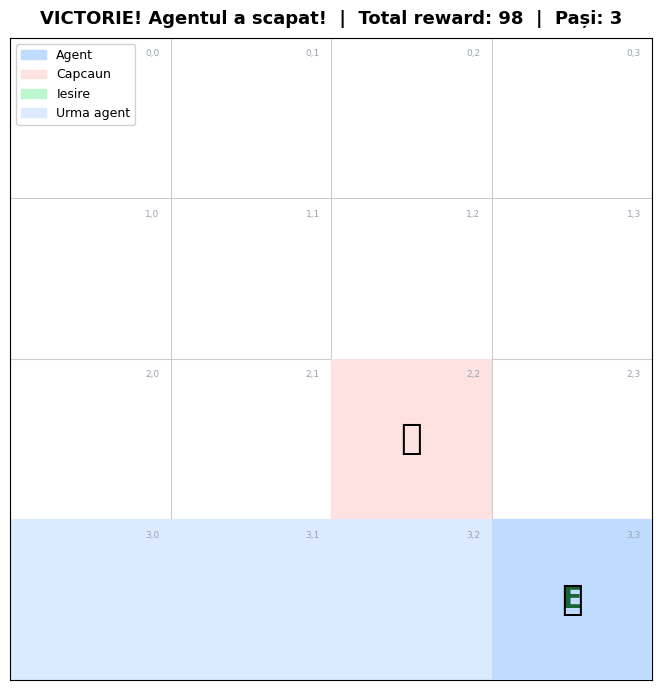

VICTORIE! Agentul a scapat!


In [14]:
def run_episode_visual(Q, max_steps=40, delay=0.5, show_policy=True):
    """Rulează un episod pas cu pas cu vizualizare matplotlib."""
    ar, ac, cr, cc = reset()
    trail = []
    total_r = 0

    for t in range(max_steps):
        clear_output(wait=True)
        action = greedy(Q, ar, ac, cr, cc)
        title = (f'Pas {t+1} | Agent: ({ar},{ac}) | Capcaun: ({cr},{cc}) | '
                 f'Actiune: {ACTION_NAMES[action]} {ACTION_ARROWS[action]} | '
                 f'Reward acumulat: {total_r}')
        render_grid(ar, ac, cr, cc, trail=trail, title=title,
                    q_table=Q, show_policy=show_policy)

        nar, nac, ncr, ncc, reward, done, info = step(ar, ac, cr, cc, action)
        trail.append((ar, ac))
        if len(trail) > 6: trail.pop(0)
        ar, ac, cr, cc = nar, nac, ncr, ncc
        total_r += reward
        time.sleep(delay)

        if done:
            clear_output(wait=True)
            msg = ('VICTORIE! Agentul a scapat!' if info == 'win'
                   else 'PRINS! Capcaunul a castigat.')
            render_grid(ar, ac, cr, cc, trail=trail,
                        title=f'{msg}  |  Total reward: {total_r}  |  Pași: {t+1}')
            print(msg)
            return info

    clear_output(wait=True)
    render_grid(ar, ac, cr, cc, trail=trail,
                title=f'⏱ Timeout — Total reward: {total_r}')
    print('⏱ Timeout — agentul nu a reusit in timp.')
    return 'timeout'


# Rulează demo (show_policy=True afișează săgețile politicii Q)
result = run_episode_visual(Q, delay=0.5, show_policy=True)